# Customer Churn Analysis
### Problem:
As a Business and Strategy Analyst, articulating the concept of "Customer Churn" necessitates a perspective that transcends a mere operational metric. Customer churn represents the **"value leakage"** within your business model.

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import warnings

warnings.filterwarnings('ignore')

In [2]:
# Preprocessors
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [3]:
# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [80]:
# Evaluators
from sklearn.model_selection import KFold, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import precision_score, recall_score, fbeta_score

In [5]:
df = pd.read_csv("data.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df = df.drop(["customerID"], axis = 1)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [8]:
df.shape

(7043, 20)

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## EDA

In [10]:
df.isna().any()

gender              False
SeniorCitizen       False
Partner             False
Dependents          False
tenure              False
PhoneService        False
MultipleLines       False
InternetService     False
OnlineSecurity      False
OnlineBackup        False
DeviceProtection    False
TechSupport         False
StreamingTV         False
StreamingMovies     False
Contract            False
PaperlessBilling    False
PaymentMethod       False
MonthlyCharges      False
TotalCharges        False
Churn               False
dtype: bool

In [11]:
df[df["TotalCharges"]==" "]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [13]:
df.iloc[df["TotalCharges"]==" "]=np.nan

In [14]:
df.isna().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

## Class-imbalanced Data
As you can see Churn distribution is imbalanced and you must make a decision which strategy to choose
#### Data-Level Methods
Changing Data for eliminating
- **Oversampling**
  - Random Oversampling
  - SMOTE
  - Borderline-SMOTE
  - ADASYN
  - KMeans-SMOTE

- **Undersampling**
  - Random Undersampling
  - Tomek Links
  - NearMiss
  - Edited Nearest Neighbours (ENN)
- **Hybrid**
  - SMOTE + Tomek Links
  - SMOTE + ENN

#### Algorithm-Level Methods
- class_weight='balanced'<br>
For instance, this models SGDClassifier، LogisticRegression، LinearSVC
- Cost-sensitive learning
- Weighted loss
- Focal Loss
- Threshold Moving

#### Model
- XGBoost
- LightGBM
- CatBoost
- Balanced Random Forest
- EasyEnsemble

#### Ensemble Methods
- Bagging
- Boosting
- Balanced Bagging
- EasyEnsemble
- RUSBoost

#### Change Evaluation Metrics
Instead of `Accuracy` use:
- Precision
- Recall
- F1-score
- PR-AUC
- ROC-AUC
- Matthews Correlation Coefficient (MCC)
- Balanced Accuracy

#### My Plan
`Algorithm-Level Methods` & `Model` & `Ensemble Methods`

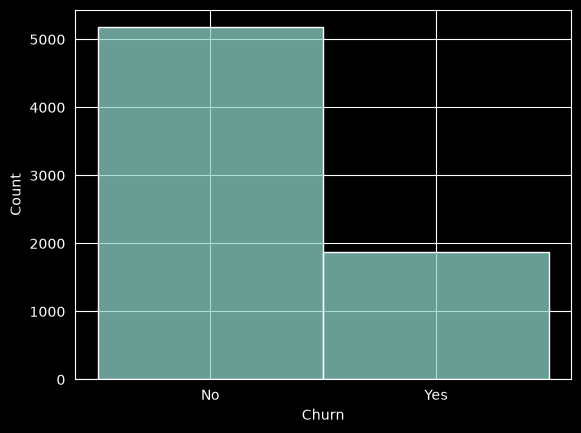

In [15]:
sns.histplot(data=df['Churn'], cbar=True)
plt.show()

In [16]:
labels_ = ["Yes", "No"]
fig = go.Figure(data=go.Pie(labels=labels_, values=df['Churn'].value_counts(), name='Churn'))
# Use `hole` to create a donut-like pie chart
fig.update_traces(hole=.4, hoverinfo="label+percent+name", textfont_size=16)
fig.update_layout(
    title_text="Churn Distributions",
    # Add annotations in the center of the donut pies.
    annotations=[dict(text='Churn', x=0.5, y=0.5, font_size=20, showarrow=False)])
fig.show()

In [17]:
female_No = df["Churn"][df["Churn"] == "No"].groupby(by = df.gender).count()["Female"]
male_No = df["Churn"][df["Churn"] == "No"].groupby(by = df.gender).count()["Male"]

female_Yes = df["Churn"][df["Churn"] == "Yes"].groupby(by = df.gender).count()["Female"]
male_Yes = df["Churn"][df["Churn"] == "Yes"].groupby(by = df.gender).count()["Male"]

churn_No = df["Churn"][df["Churn"] == "No"].count()
churn_Yes = df["Churn"][df["Churn"] == "Yes"].count()

churn_labels=["Churn: Yes", "Churn: No"]
churn_values = [churn_Yes, churn_No]

gender_labels = ["Female", "Male", "Female", "Male"]
gender_values = [female_Yes, male_Yes, female_No, male_No]

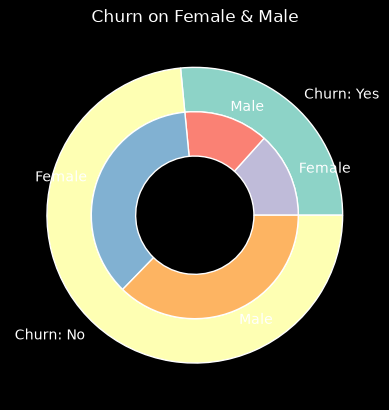

In [18]:
fig, ax = (plt.subplots())

size = 0.3

ax.pie(
    churn_values,
    labels=churn_labels,
    radius=1,
    wedgeprops=dict(width=size, edgecolor='w')
)

ax.pie(
    gender_values ,
    labels=gender_labels,
    radius=1-size,
    wedgeprops=dict(width=size, edgecolor='w')
)

ax.set(aspect="equal", title='Churn on Female & Male')
plt.show()

In [19]:
print("Churn on Female & Male\n")
female_No_ratio = 100 * female_No / churn_No
male_No_ratio = 100 * male_No / churn_No

print(f"{female_No_ratio:.2f}% of unchurned Customers are female.")
print(f"{male_No_ratio:.2f}% of unchurned Customers are male.")
print()

female_Yes_ratio = 100 * female_Yes / churn_Yes
male_Yes_ratio = 100 * male_Yes / churn_Yes

print(f"{female_Yes_ratio:.2f}% of churned Customers are female.")
print(f"{male_Yes_ratio:.2f}% of churned Customers are male.")
print()

churn_No_by_female = 100 * female_No/(female_No + female_Yes)
churn_Yes_by_female = 100 * female_Yes/(female_No + female_Yes)

print(f"{churn_No_by_female:.2f}% of female are NOT churned.")
print(f"{churn_Yes_by_female:.2f}% of female are churned.")
print()

churn_No_by_male = 100 * male_No/(male_No + male_Yes)
churn_Yes_by_male = 100 * male_Yes/(male_No + male_Yes)

print(f"{churn_No_by_male:.2f}% of male are NOT churned.")
print(f"{churn_Yes_by_male:.2f}% of male are churned.")
print()

Churn on Female & Male

49.27% of unchurned Customers are female.
50.73% of unchurned Customers are male.

50.24% of churned Customers are female.
49.76% of churned Customers are male.

73.08% of female are NOT churned.
26.92% of female are churned.

73.84% of male are NOT churned.
26.16% of male are churned.



## Churn on Contract

In [20]:
df['Contract'].unique()

<ArrowStringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

In [21]:
fig = px.histogram(df, x="Churn", color = "Contract", barmode = "group", title = "<b>Customer contract distribution<b>")
fig.update_layout(width=700, height=500, bargap=0.2)
fig.show()

## Data Cleanig

In [22]:
binary_cols = [col for col in df.columns if set(df[col].unique())=={"Yes", "No"}]
binary_cols

['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

In [23]:
df[binary_cols] = df[binary_cols].replace({"Yes": 1, "No": 0})

In [24]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [25]:
y_train = y_train.astype('int')
y_test = y_test.astype('int')

In [26]:
X_train.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='str')

In [27]:
cat_ = ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',  'StreamingMovies',  'Contract', 'PaymentMethod']

In [28]:
one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# fit and transform for train dataset
train_encoded_array = one_hot_encoder.fit_transform(X_train[cat_])

# only transform for test dataset
test_encoded_array = one_hot_encoder.transform(X_test[cat_])

In [29]:
X_train_cat = pd.DataFrame(train_encoded_array, columns=one_hot_encoder.get_feature_names_out(cat_), index=X_train.index)
X_train_num  = X_train.drop(cat_, axis=1)
X_train = pd.concat([X_train_num, X_train_cat], axis=1)

In [30]:
X_test_cat = pd.DataFrame(test_encoded_array, columns=one_hot_encoder.get_feature_names_out(cat_), index=X_test.index)
X_test_num  = X_test.drop(cat_, axis=1)
X_test = pd.concat([X_test_num, X_test_cat], axis=1)

In [31]:
imputer = SimpleImputer(missing_values=np.nan, strategy='median')

imputer_val_train = imputer.fit_transform(X_train)
imputer_val_test = imputer.transform(X_test)

X_train = pd.DataFrame(imputer_val_train, columns=imputer.get_feature_names_out(), index=X_train.index)
X_test = pd.DataFrame(imputer_val_test, columns=imputer.get_feature_names_out(), index=X_test.index)

In [32]:
X_train.dtypes

SeniorCitizen                              float64
Partner                                    float64
Dependents                                 float64
tenure                                     float64
PhoneService                               float64
PaperlessBilling                           float64
MonthlyCharges                             float64
TotalCharges                               float64
gender_Female                              float64
gender_Male                                float64
MultipleLines_No                           float64
MultipleLines_No phone service             float64
MultipleLines_Yes                          float64
InternetService_DSL                        float64
InternetService_Fiber optic                float64
InternetService_No                         float64
OnlineSecurity_No                          float64
OnlineSecurity_No internet service         float64
OnlineSecurity_Yes                         float64
OnlineBackup_No                

In [33]:
X_test.dtypes

SeniorCitizen                              float64
Partner                                    float64
Dependents                                 float64
tenure                                     float64
PhoneService                               float64
PaperlessBilling                           float64
MonthlyCharges                             float64
TotalCharges                               float64
gender_Female                              float64
gender_Male                                float64
MultipleLines_No                           float64
MultipleLines_No phone service             float64
MultipleLines_Yes                          float64
InternetService_DSL                        float64
InternetService_Fiber optic                float64
InternetService_No                         float64
OnlineSecurity_No                          float64
OnlineSecurity_No internet service         float64
OnlineSecurity_Yes                         float64
OnlineBackup_No                

In [34]:
df_result = df.copy()
X_all = pd.get_dummies(df.drop('Churn', axis=1), drop_first=True)
X_all

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_1,Dependents_1,PhoneService_1,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_1,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,1.0,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0.0,34.0,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0.0,2.0,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0.0,45.0,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0.0,2.0,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,24.0,84.80,1990.50,True,True,True,True,False,True,...,False,True,False,True,True,False,True,False,False,True
7039,0.0,72.0,103.20,7362.90,False,True,True,True,False,True,...,False,True,False,True,True,False,True,True,False,False
7040,0.0,11.0,29.60,346.45,False,True,True,False,True,False,...,False,False,False,False,False,False,True,False,True,False
7041,1.0,4.0,74.40,306.60,True,True,False,True,False,True,...,False,False,False,False,False,False,True,False,False,True


## Cross Validation

In [35]:
models =[
    ('Logistic Regression', LogisticRegression(solver='liblinear', random_state = 42, class_weight='balanced', C=2)),
    ('Decision Tree Classifier', DecisionTreeClassifier(criterion = 'entropy', random_state = 42)),
    ('SVC', SVC(kernel = 'linear', random_state = 0)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, criterion = 'entropy', random_state = 42)),
    ('XGBoost', XGBClassifier(n_estimators=100, criterion = 'entropy', random_state = 42)),
    ]

## Evaluating the model Results

In [36]:
acc_results =[]
auc_results =[]
names = []

result_col = ["Algorithm", "ROC AUC Mean", "ROC AUC STD", "Accuracy Mean", "Accuracy STD"]
model_results = pd.DataFrame(columns = result_col)

i=0

# Stratified K-fold cross validation
for name, model in models:
    names.append(name)
    kfold = StratifiedKFold(n_splits=5, random_state=64, shuffle=True)

    cv_acc_results = cross_val_score(
        model,
        X_train,
        y_train,
        cv = kfold,
        scoring="accuracy")

    cv_auc_results = cross_val_score(
        model,
        X_train,
        y_train,
        cv = kfold,
        scoring="roc_auc")
    acc_results.append(cv_acc_results)
    auc_results.append(cv_auc_results)

    model_results.loc[i] = [name,
                           round(cv_auc_results.mean()*100,2),
                           round(cv_auc_results.std()*100,2),
                           round(cv_acc_results.mean()*100,2),
                           round(cv_acc_results.std()*100,2)]
    i+=1

model_results.sort_values(by = ['ROC AUC Mean'], ascending=False)

,Algorithm,ROC AUC Mean,ROC AUC STD,Accuracy Mean,Accuracy STD
0,Logistic Regression,84.53,1.25,74.92,1.32
3,Random Forest,82.14,1.50,79.11,1.27
4,XGBoost,81.70,1.12,78.15,1.05
2,SVC,80.44,1.65,79.34,1.02
1,Decision Tree Classifier,65.79,1.54,72.79,1.17


`Logistic Regression` represent best `ROC AUC`

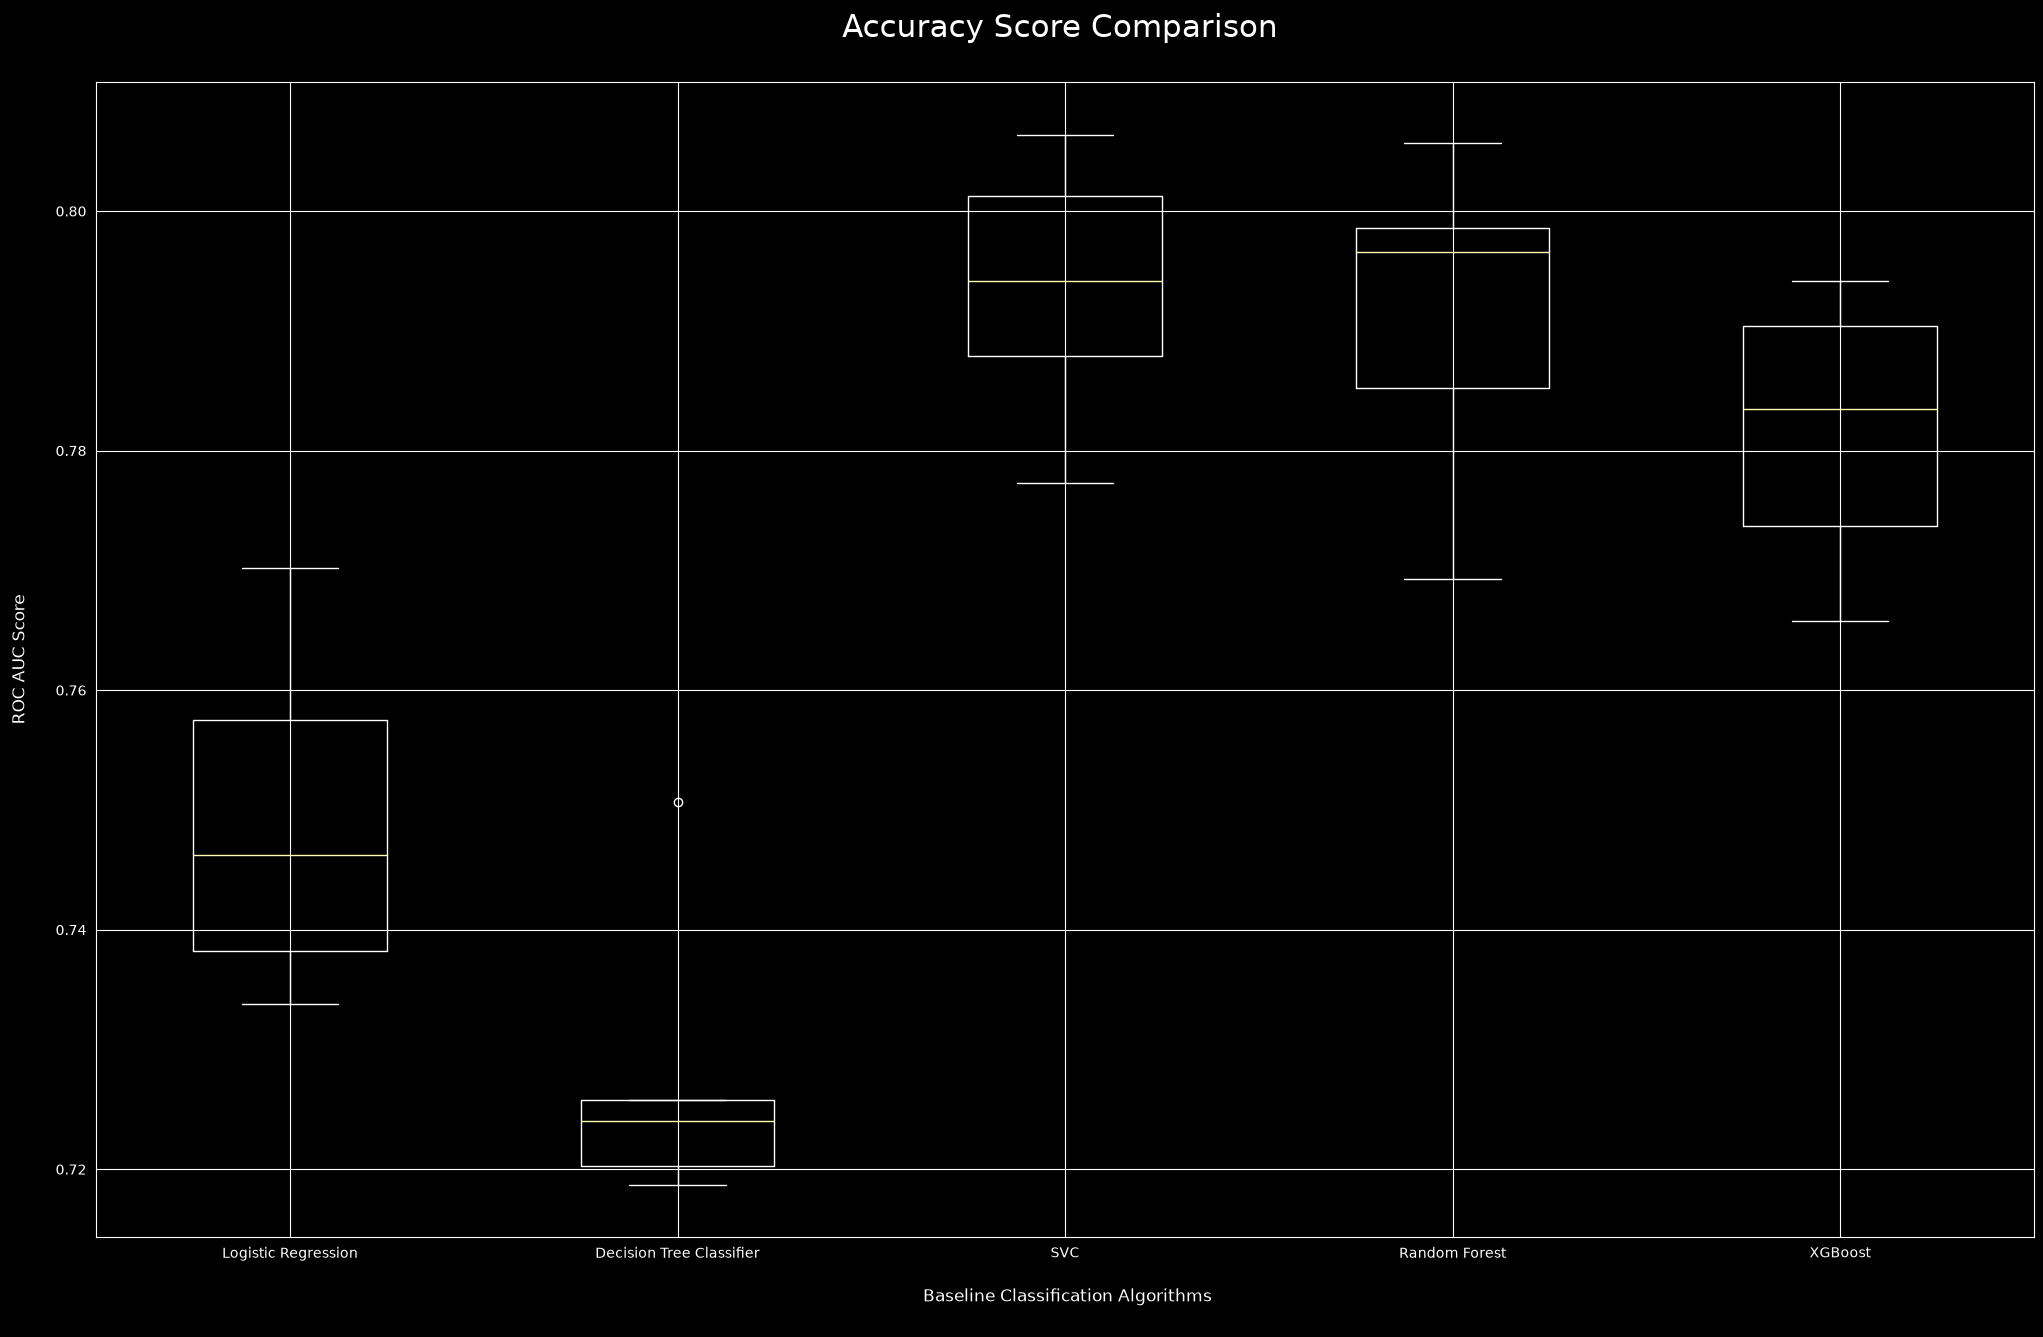

In [77]:
fig = plt.figure(figsize=(25,15))
ax = fig.add_subplot(111)
plt.boxplot(acc_results)
ax.set_xticklabels(names)

plt.ylabel('ROC AUC Score\n',
horizontalalignment="center",fontstyle = "normal",
fontsize = "large", fontfamily = "sans-serif")

plt.xlabel('\n Baseline Classification Algorithms\n',
horizontalalignment="center",fontstyle = "normal",
fontsize = "large", fontfamily = "sans-serif")

plt.title('Accuracy Score Comparison \n',
horizontalalignment="center", fontstyle = "normal",
fontsize = "22", fontfamily = "sans-serif")

plt.xticks(rotation=0, horizontalalignment="center")
plt.yticks(rotation=0, horizontalalignment="right")
plt.show()

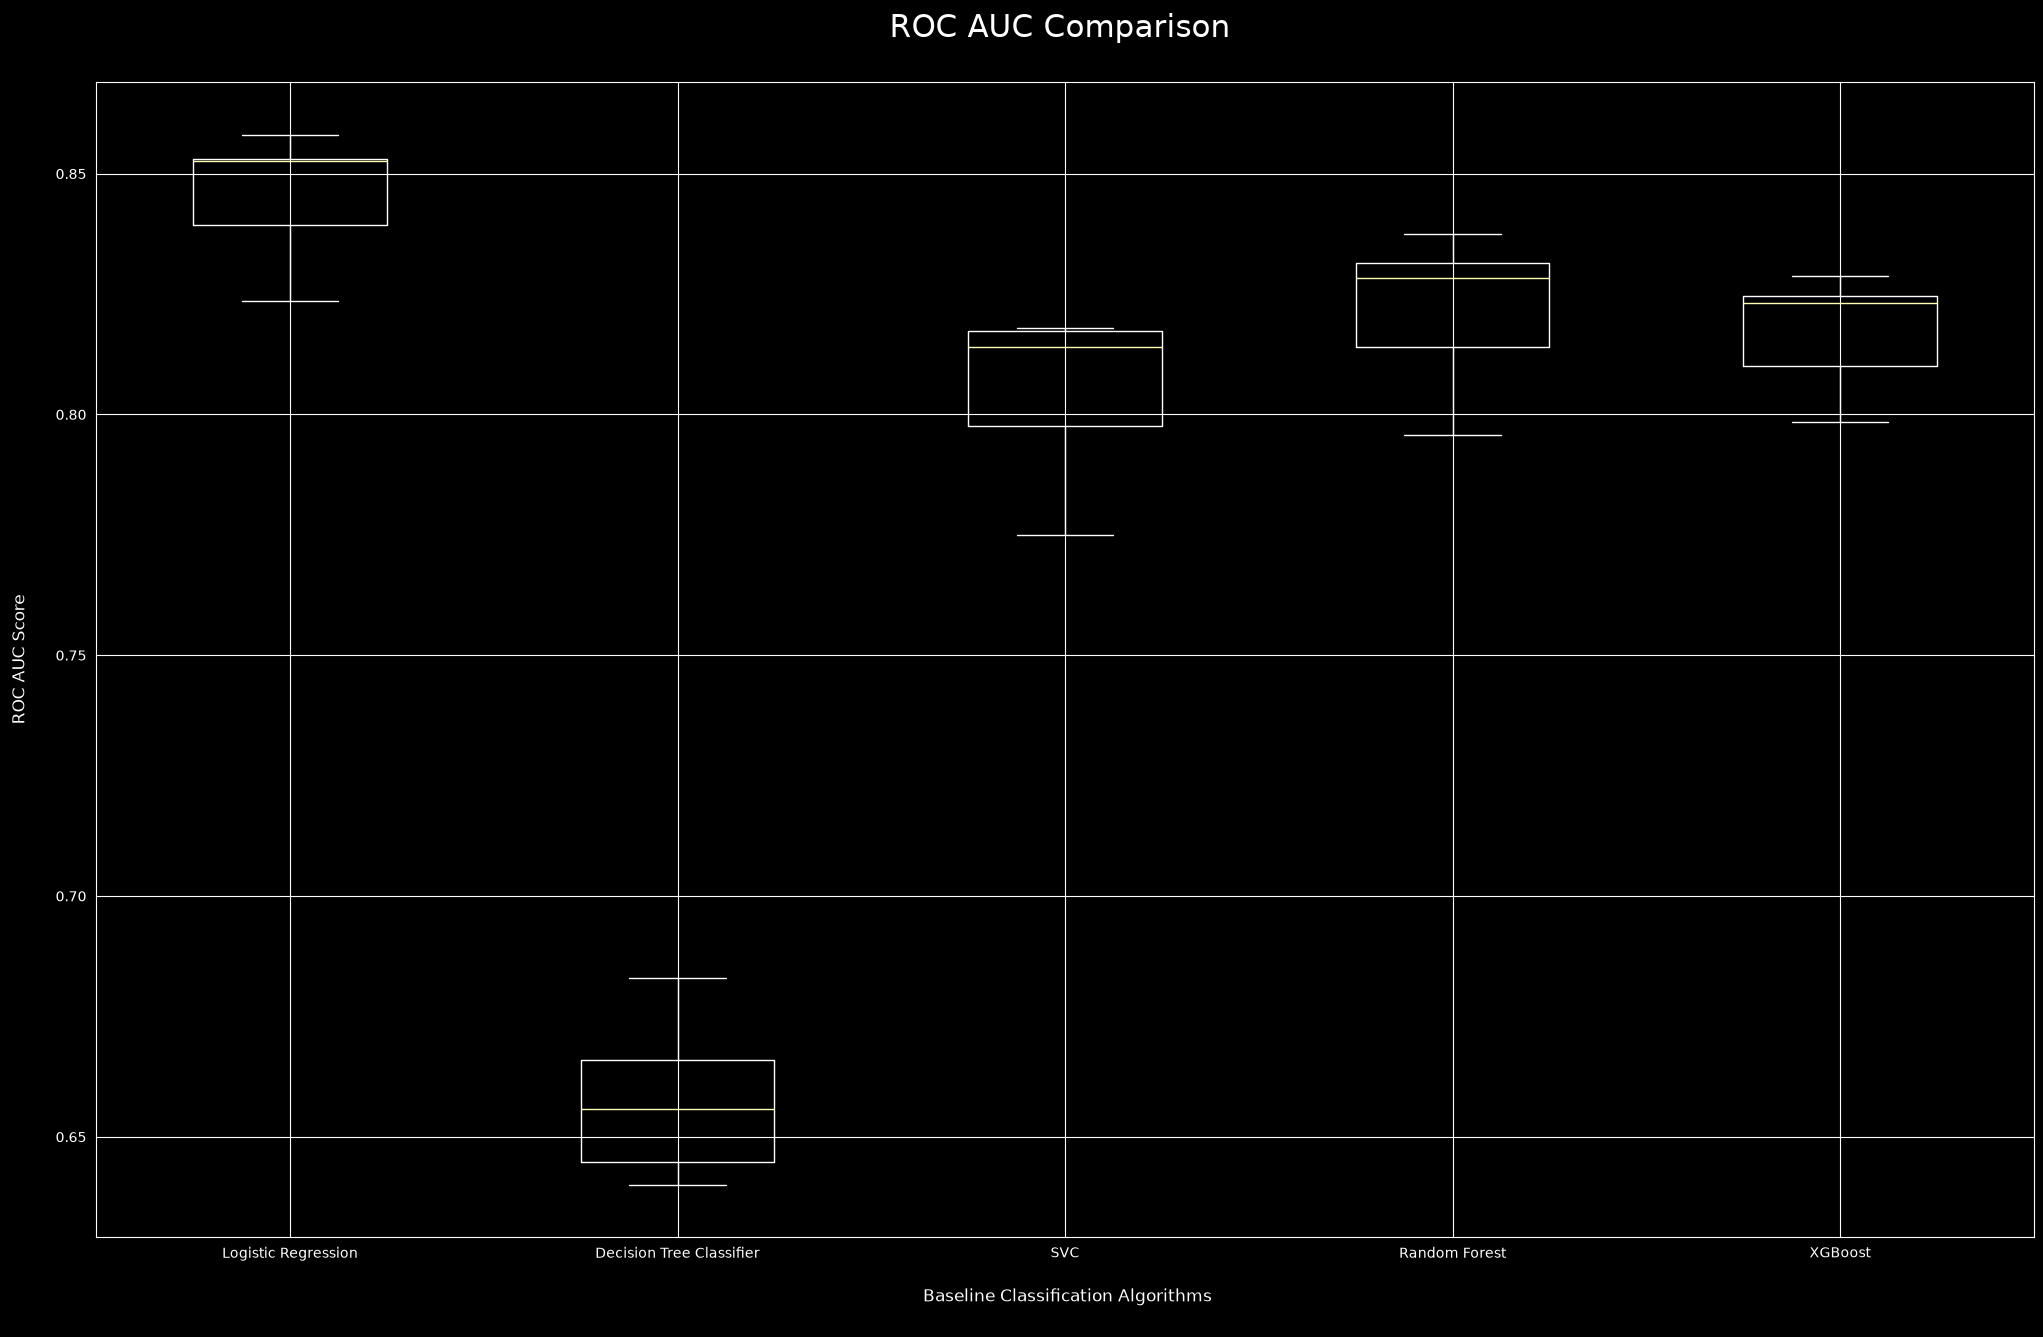

In [78]:
fig = plt.figure(figsize=(25,15))
ax = fig.add_subplot(111)
plt.boxplot(auc_results)
ax.set_xticklabels(names)

plt.ylabel('ROC AUC Score\n',
horizontalalignment="center",fontstyle = "normal",
fontsize = "large", fontfamily = "sans-serif")

plt.xlabel('\n Baseline Classification Algorithms\n',
horizontalalignment="center",fontstyle = "normal",
fontsize = "large", fontfamily = "sans-serif")

plt.title('ROC AUC Comparison \n',
horizontalalignment="center", fontstyle = "normal",
fontsize = "22", fontfamily = "sans-serif")

plt.xticks(rotation=0, horizontalalignment="center")
plt.yticks(rotation=0, horizontalalignment="right")
plt.show()

## predictive models

In [81]:
#evaluation of results
def model_evaluation(y_test, y_pred, model_name):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    f2 = fbeta_score(y_test, y_pred, beta = 2.0)
    roc_auc = roc_auc_score(y_test, y_pred)

    results = pd.DataFrame([[model_name, acc, prec, rec, f1, f2, roc_auc]],
                       columns = ["Model", "Accuracy", "Precision", "Recall",
                                 "F1 SCore", "F2 Score", "ROC AUC"])
    results = results.sort_values(["Precision", "Recall", "F2 Score"], ascending = False)
    return results

In [ ]:
# Train models
# lr = LogisticRegression(class_weight='balanced', random_state=64)
# lr.fit(X_train, y_train)
# lr_predict = lr.predict(X_test)

### Logistic Regression

In [37]:
# lr = LogisticRegression(class_weight='balanced', random_state=64)
# lr.fit(X_train, y_train)

In [38]:
# lr_predict = lr.predict(X_test)
# lr_report = classification_report(y_test, lr_predict)
# print(lr_report)

In [39]:
# ConfusionMatrixDisplay.from_predictions(y_test, lr_predict)

In [40]:
# precision_recall_fscore_support(y_test, lr_predict)

In [41]:
# lr_prob = lr.predict_proba(X_test)[:,1]
# RocCurveDisplay.from_predictions(y_test, lr_prob)

#### Regularization
find `C` value for best f1_score <br>
`C = 2` make a best result for this model

In [42]:
# c_candidate = [.1, .5, 1, 1.5, 1.75, 2, 2.5, 2.7]
# lr_f1_score = []
# for i in c_candidate:
#     lr = LogisticRegression(class_weight='balanced', random_state=64, C=i)
#     lr.fit(X_train, y_train)
#     lr_predict = lr.predict(X_test)
#     lr_f1_score.append(f1_score(y_test, lr_predict))
#
# lr_f1_score

#### Precision vs Recall Trade off

In [43]:
# lr = LogisticRegression(class_weight='balanced', random_state=64, C=2)
# lr.fit(X_train, y_train)
# y_score = lr.decision_function(X_train)

In [44]:
# precision, recall, thresholds = precision_recall_curve(y_train, y_score)

In [45]:
# precision

In [46]:
# recall

In [47]:
# thresholds

In [48]:
# f1_score = 2/(1/recall + 1/precision)
# f1_score

In [49]:
# plt.plot( thresholds, precision[:-1], label="Precision")
# plt.plot( thresholds, recall[:-1], label="Recall")
# plt.title('Precision-Recall curve')
# plt.xlabel('Thresholds')
# plt.ylabel('Score')
# plt.legend()
# plt.show()

In [50]:
# print(f"precision: {precision}, recall: {recall}, thresholds: {thresholds}")

In [51]:
# plt.plot( thresholds, f1_score[:-1], label="F1 score")
# plt.title('F1 score curve')
# plt.xlabel('Thresholds')
# plt.ylabel('F1 Score')
# plt.legend()
# plt.show()

In [52]:
# lr_roc_auc_score = roc_auc_score(y_true=y_test, y_score=lr_prob)
# lr_roc_auc_score

-------

### Decision Tree

In [53]:
# dtc = DecisionTreeClassifier(random_state=42, class_weight='balanced')
# dtc.fit(X_train, y_train)

In [54]:
# dtc_predict = dtc.predict(X_test)
# dtc_report = classification_report(y_test, dtc_predict)
# print(dtc_report)

In [55]:
# ConfusionMatrixDisplay.from_predictions(y_test, dtc_predict)

In [56]:
# dtc_prob = dtc.predict_proba(X_test)[:,1]
# RocCurveDisplay.from_predictions(y_test, dtc_prob)

In [57]:
# dtc_roc_auc_score = roc_auc_score(y_true=y_test, y_score=dtc_prob)
# dtc_roc_auc_score

---

### Random Forest

In [58]:
# rfc = RandomForestClassifier(random_state=42, class_weight='balanced')
# rfc.fit(X_train, y_train)

In [59]:
# rfc_predict = rfc.predict(X_test)
# rfc_report = classification_report(y_test, rfc_predict)
# print(rfc_report)

In [60]:
# ConfusionMatrixDisplay.from_predictions(y_test, rfc_predict)

In [61]:
# rfc_prob = rfc.predict_proba(X_test)[:,1]
# RocCurveDisplay.from_predictions(y_test, rfc_prob)

In [62]:
# score_array = []
# for each in range(1,100):
#     rf_loop = RandomForestClassifier(n_estimators = each, random_state = 1)
#     rf_loop.fit(X_train,y_train)
#     score_array.append(rf_loop.score(X_test,y_test))
#
# score_array

In [63]:
# rfc_roc_auc_score = roc_auc_score(y_true=y_test, y_score=rfc_prob)
# rfc_roc_auc_score

----

### Support Vector Classifier

In [64]:
# svc = SVC(random_state=64, class_weight='balanced', C=2)
# svc.fit(X_train, y_train)

In [65]:
# svc_predict = svc.predict(X_test)
# svc_report = classification_report(y_test, svc_predict)
# print(svc_report)

In [66]:
# ConfusionMatrixDisplay.from_predictions(y_test, svc_predict)

In [67]:
# svc_prob = rfc.predict_proba(X_test)[:,1]
# RocCurveDisplay.from_predictions(y_test, svc_prob)

In [68]:
# svc_roc_auc_score = roc_auc_score(y_true=y_test, y_score=svc_prob)
# svc_roc_auc_score

In [69]:
# print("=========== Compare models ===========")
# print(f"Logistic Regression: {lr_roc_auc_score}")
# print(f"Decision Tree: {dtc_roc_auc_score}")
# print(f"Random Forest: {rfc_roc_auc_score}")
# print(f"SVM: {svc_roc_auc_score}")

##### Logistic Regression won the battle

In [70]:
# X_all = pd.concat([X_train, X_test])
# df_result['churn_probability'] = lr.predict_proba()

In [71]:
# fig = plt.figure(figsize=(25,15))
# ax = fig.add_subplot(111)
# plt.boxplot(acc_results)
# ax.set_xticklabels(names)
#
# plt.ylabel('ROC AUC Score\n',
# horizontalalignment="center",fontstyle = "normal",
# fontsize = "large", fontfamily = "sans-serif")
#
# plt.xlabel('\n Baseline Classification Algorithms\n',
# horizontalalignment="center",fontstyle = "normal",
# fontsize = "large", fontfamily = "sans-serif")
#
# plt.title('Accuracy Score Comparison \n',
# horizontalalignment="center", fontstyle = "normal",
# fontsize = "22", fontfamily = "sans-serif")
#
# plt.xticks(rotation=0, horizontalalignment="center")
# plt.yticks(rotation=0, horizontalalignment="right")
# plt.show()


In [72]:
# fig = plt.figure(figsize=(25,15))
# ax = fig.add_subplot(111)
# plt.boxplot(auc_results)
# ax.set_xticklabels(names)
#
# plt.ylabel('ROC AUC Score\n',
# horizontalalignment="center",fontstyle = "normal",
# fontsize = "large", fontfamily = "sans-serif")
#
# plt.xlabel('\n Baseline Classification Algorithms\n',
# horizontalalignment="center",fontstyle = "normal",
# fontsize = "large", fontfamily = "sans-serif")
#
# plt.title('ROC AUC Comparison \n',
# horizontalalignment="center", fontstyle = "normal",
# fontsize = "22", fontfamily = "sans-serif")
#
# plt.xticks(rotation=0, horizontalalignment="center")
# plt.yticks(rotation=0, horizontalalignment="right")
# plt.show()


## Random Forest

In [73]:
# score_array = []
# for each in range(1,100):
#     rf_loop = RandomForestClassifier(n_estimators = each, random_state = 1)
#     rf_loop.fit(X_train,y_train)
#     score_array.append(rf_loop.score(X_test,y_test))
#
# score_array

In [76]:
# import xgboost as xgb
#
# xg = xgb.XGBClassifier(tree_method="hist", device="cuda")
# xg.fit(X_train, y_train)
